# Memory in Sequence Models
## From Forget Gates to KV Caches to State Spaces

**MAT 4953 / MAT 6973 — Mathematical Foundations of AI** (Spring 2026, UTSA)

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eduenez/MathAIspring2026UTSA/blob/main/code/sequence_memory_models.ipynb)

---

Every sequence model must answer the same fundamental question: **how should we compress the history $(x_1, \dots, x_{t-1})$ into a finite representation that is useful for predicting $x_t$?**

Different architectures give different answers, and the mathematical structure of each answer determines the model's capacity, speed, and failure modes:

1. **RNN hidden state** — a fixed-size vector updated recurrently; suffers from vanishing gradients.
2. **LSTM / GRU gates** — learned gates control what to remember and forget; the "constant error carousel" mitigates gradient decay.
3. **Transformer KV cache** — explicit storage of all past key-value pairs; perfect recall but $O(T)$ memory and $O(T)$ per-step cost.
4. **State-space models (Mamba)** — a structured linear recurrence that can be computed as either an RNN or a convolution; linear scaling in $T$.

**Prerequisites:** Familiarity with RNNs and Transformers from the [Architectures Overview](dnn_architectures_overview.ipynb), and autoregressive generation from the [Generative Models](generative_models.ipynb) lesson.

---
# 0. Setup

This notebook runs on **Google Colab** (GPU/TPU/CPU) and in a **local Jupyter environment** (CPU).

- **Google Colab**: click *Open in Colab* above. Go to *Runtime → Change runtime type* and select
  **GPU** or **TPU v2** for faster training.
- **Local**: install dependencies with `pip install -r requirements.txt` from the repository root,
  then open this file with `jupyter notebook` or `jupyter lab`.

The setup cell below automatically detects the available hardware and configures JAX accordingly.

In [9]:
# @title Runtime & backend setup (run first)
import os, subprocess, platform

def _detect_platform():
    try:
        import requests
        resp = requests.get(
            'http://metadata.google.internal/computeMetadata/v1/instance/attributes/tpu-name',
            headers={'Metadata-Flavor': 'Google'}, timeout=2)
        if resp.ok:
            return 'tpu'
    except Exception:
        pass
    try:
        result = subprocess.run(
            ['nvidia-smi', '--query-gpu=name', '--format=csv,noheader'],
            capture_output=True, text=True, timeout=5)
        if result.returncode == 0 and result.stdout.strip():
            return 'gpu'
    except Exception:
        pass
    if platform.system() == 'Darwin':
        return 'cpu_macos'
    return 'cpu'

_platform = _detect_platform()
print(f'Platform: {_platform.upper()}')

os.environ['KERAS_BACKEND'] = 'jax'
if _platform == 'tpu':
    pass
elif _platform == 'gpu':
    os.environ['JAX_PLATFORMS'] = 'cuda'
else:
    os.environ['JAX_PLATFORMS'] = 'cpu'

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from matplotlib.lines import Line2D
from IPython.display import display, HTML

import jax
import jax.numpy as jnp
import keras
from keras import layers, ops

%matplotlib inline
np.random.seed(42)
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 13, 'figure.dpi': 100})

print(f'JAX devices : {jax.devices()}')
print(f'Keras version: {keras.__version__}')
print(f'Keras backend: {keras.backend.backend()}')

Platform: CPU_MACOS
JAX devices : [CpuDevice(id=0)]
Keras version: 3.14.0
Keras backend: jax


---
# 1. The Memory Problem

## 1.1 What does "memory" mean for a sequence model?

Consider a model processing a sequence $(x_1, x_2, \dots, x_T)$. At time step $t$, the model must produce an output based on the history $x_{<t} = (x_1, \dots, x_{t-1})$. The **memory** of the model is the mechanism by which it stores and retrieves information from this history.

There are two fundamental axes along which memory mechanisms differ:

| | **Fixed-size state** | **Growing storage** |
|---|---|---|
| **Description** | Compress all history into a vector $\mathbf{h}_t \in \mathbb{R}^d$ of fixed dimension | Store a table of $(\mathbf{k}_i, \mathbf{v}_i)$ pairs that grows with $t$ |
| **Per-step cost** | $O(d^2)$ (matrix-vector multiply) | $O(t \cdot d)$ (attend over all stored entries) |
| **Total memory** | $O(d)$ — constant | $O(T \cdot d)$ — linear in sequence length |
| **Examples** | RNN, LSTM, GRU, SSM/Mamba | Transformer KV cache |
| **Failure mode** | Lossy compression (forgetting) | Memory and compute blow up for long $T$ |

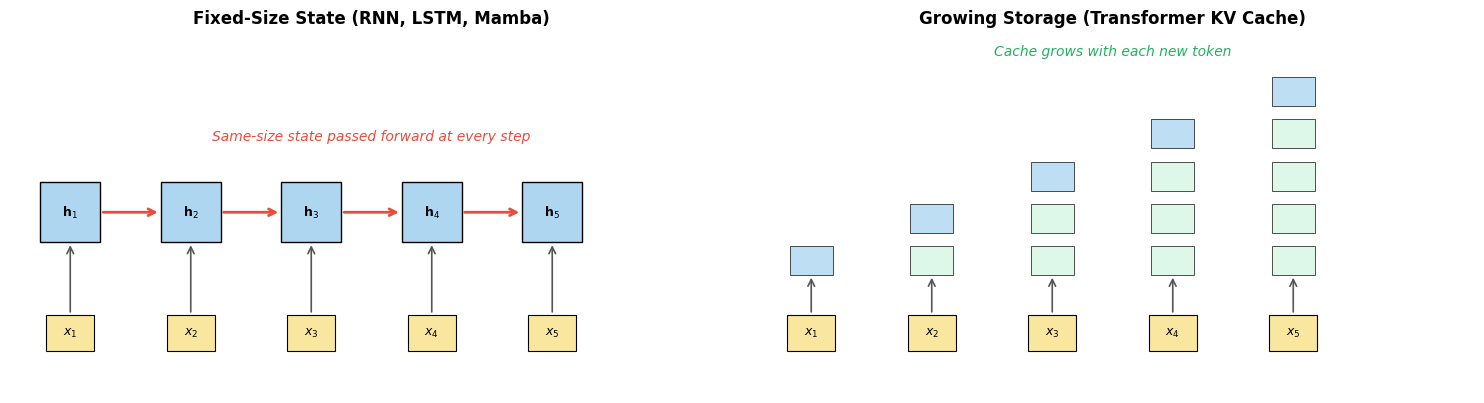

In [10]:
# Diagram: the two memory paradigms
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# --- Left: Fixed-size state (RNN/LSTM/Mamba) ---
ax = axes[0]
ax.set_xlim(-0.5, 5.5); ax.set_ylim(-0.5, 2.5)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title('Fixed-Size State (RNN, LSTM, Mamba)', fontsize=12, fontweight='bold')

for t in range(5):
    # Input
    ax.add_patch(plt.Rectangle((t - 0.2, -0.15), 0.4, 0.3,
                 facecolor='#f9e79f', edgecolor='k', linewidth=0.8))
    ax.text(t, 0, f'$x_{t+1}$', ha='center', va='center', fontsize=9)
    # Hidden state
    ax.add_patch(plt.Rectangle((t - 0.25, 0.75), 0.5, 0.5,
                 facecolor='#aed6f1', edgecolor='k', linewidth=1))
    ax.text(t, 1, f'$\\mathbf{{h}}_{t+1}$', ha='center', va='center', fontsize=9)
    # Arrow: input -> hidden
    ax.annotate('', xy=(t, 0.75), xytext=(t, 0.15),
                arrowprops=dict(arrowstyle='->', color='#555', lw=1.2))
    # Arrow: hidden -> hidden (recurrence)
    if t < 4:
        ax.annotate('', xy=(t + 0.75, 1), xytext=(t + 0.25, 1),
                    arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=2))

ax.text(2.5, 1.6, 'Same-size state passed forward at every step',
        ha='center', fontsize=10, style='italic', color='#e74c3c')

# --- Right: Growing storage (Transformer KV cache) ---
ax = axes[1]
ax.set_xlim(-0.5, 5.5); ax.set_ylim(-0.5, 2.5)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title('Growing Storage (Transformer KV Cache)', fontsize=12, fontweight='bold')

for t in range(5):
    # Input
    ax.add_patch(plt.Rectangle((t - 0.2, -0.15), 0.4, 0.3,
                 facecolor='#f9e79f', edgecolor='k', linewidth=0.8))
    ax.text(t, 0, f'$x_{t+1}$', ha='center', va='center', fontsize=9)
    # KV pair stored
    for s in range(t + 1):
        y_pos = 0.6 + s * 0.35
        ax.add_patch(plt.Rectangle((t - 0.18, y_pos - 0.12), 0.36, 0.24,
                     facecolor='#d5f5e3' if s < t else '#aed6f1',
                     edgecolor='k', linewidth=0.6, alpha=0.8))
    ax.annotate('', xy=(t, 0.48), xytext=(t, 0.15),
                arrowprops=dict(arrowstyle='->', color='#555', lw=1.2))

ax.text(2.5, 2.3, 'Cache grows with each new token',
        ha='center', fontsize=10, style='italic', color='#27ae60')

plt.tight_layout()
plt.show()

---
# 2. LSTM: Gated Memory

## 2.1 The vanishing gradient problem (recap)

Recall from the [Architectures Overview](dnn_architectures_overview.ipynb) that a simple RNN updates its hidden state by

$$\mathbf{h}_t = \sigma(W_h \mathbf{h}_{t-1} + W_x \mathbf{x}_t + \mathbf{b}).$$

The gradient of the loss at time $T$ with respect to $\mathbf{h}_t$ involves the product

$$\frac{\partial \mathbf{h}_T}{\partial \mathbf{h}_t} = \prod_{s=t+1}^{T} \text{diag}\!\bigl(\sigma'(\cdot)\bigr) \, W_h,$$

which either **vanishes** (if $\|W_h\| < 1$ effectively) or **explodes** (if $\|W_h\| > 1$). This means a simple RNN cannot learn dependencies that span more than $\sim$10–20 time steps.

## 2.2 The LSTM solution: the constant error carousel

The **Long Short-Term Memory** (Hochreiter & Schmidhuber, 1997) introduces a separate **cell state** $\mathbf{c}_t$ that is updated *additively*:

$$\boxed{\begin{aligned}
\mathbf{f}_t &= \sigma(W_f [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_f) && \text{(forget gate)} \\
\mathbf{i}_t &= \sigma(W_i [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_i) && \text{(input gate)} \\
\tilde{\mathbf{c}}_t &= \tanh(W_c [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_c) && \text{(candidate)} \\
\mathbf{c}_t &= \mathbf{f}_t \odot \mathbf{c}_{t-1} + \mathbf{i}_t \odot \tilde{\mathbf{c}}_t && \text{(cell update)} \\
\mathbf{o}_t &= \sigma(W_o [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_o) && \text{(output gate)} \\
\mathbf{h}_t &= \mathbf{o}_t \odot \tanh(\mathbf{c}_t) && \text{(hidden state)}
\end{aligned}}$$

**Why this fixes the gradient:** The cell state update $\mathbf{c}_t = \mathbf{f}_t \odot \mathbf{c}_{t-1} + \dots$ is *additive* — it looks like a residual connection across time. When the forget gate is close to 1, the gradient flows through $\mathbf{c}$ without decay:

$$\frac{\partial \mathbf{c}_T}{\partial \mathbf{c}_t} = \prod_{s=t+1}^{T} \text{diag}(\mathbf{f}_s) \approx I \quad \text{(when } \mathbf{f}_s \approx 1\text{)}.$$

This is the **constant error carousel**: information can persist indefinitely in the cell state as long as the forget gate stays open.

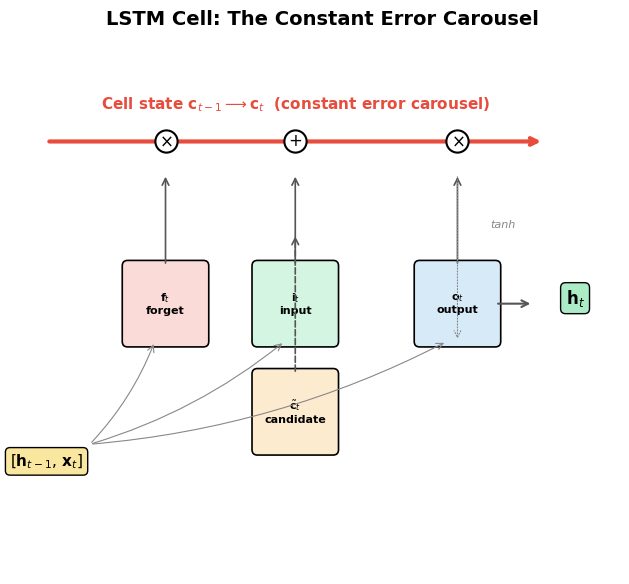

In [11]:
# Diagram: LSTM cell with gates
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(-0.5, 5); ax.set_ylim(-0.5, 4.5)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title('LSTM Cell: The Constant Error Carousel', fontsize=14, fontweight='bold')

# Cell state highway (the "carousel")
ax.annotate('', xy=(4.3, 3.5), xytext=(-0.3, 3.5),
            arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=3))
ax.text(2, 3.8, 'Cell state $\\mathbf{c}_{t-1} \\longrightarrow \\mathbf{c}_t$  '
        '(constant error carousel)', ha='center', fontsize=11,
        color='#e74c3c', fontweight='bold')

# Gates
gate_info = [
    (0.8, 2.0, '$\\mathbf{f}_t$\nforget', '#fadbd8'),
    (2.0, 2.0, '$\\mathbf{i}_t$\ninput', '#d5f5e3'),
    (2.0, 1.0, '$\\tilde{\\mathbf{c}}_t$\ncandidate', '#fdebd0'),
    (3.5, 2.0, '$\\mathbf{o}_t$\noutput', '#d6eaf8'),
]
for gx, gy, label, color in gate_info:
    ax.add_patch(FancyBboxPatch((gx - 0.35, gy - 0.35), 0.7, 0.7,
                 boxstyle='round,pad=0.05', facecolor=color,
                 edgecolor='k', linewidth=1.2))
    ax.text(gx, gy, label, ha='center', va='center', fontsize=8, fontweight='bold')

# Multiply symbols on cell state line
for cx, label in [(0.8, '$\\times$'), (2.0, '$+$'), (3.5, '$\\times$')]:
    ax.plot(cx, 3.5, 'o', markersize=16, color='white', markeredgecolor='k',
            markeredgewidth=1.5, zorder=5)
    ax.text(cx, 3.5, label, ha='center', va='center', fontsize=12, zorder=6)

# Arrows from gates to cell state
for gx in [0.8, 2.0, 3.5]:
    ax.annotate('', xy=(gx, 3.2), xytext=(gx, 2.35),
                arrowprops=dict(arrowstyle='->', color='#555', lw=1.2))

# Arrow from candidate to +
ax.annotate('', xy=(2.0, 2.65), xytext=(2.0, 1.35),
            arrowprops=dict(arrowstyle='->', color='#555', lw=1.2, linestyle='--'))

# Input x_t and h_{t-1}
ax.text(-0.3, 0.5, '$[\\mathbf{h}_{t-1},\\, \\mathbf{x}_t]$', fontsize=11,
        ha='center', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#f9e79f', edgecolor='k'))
for gx in [0.8, 2.0, 3.5]:
    ax.annotate('', xy=(gx - 0.1, 1.65), xytext=(0.1, 0.7),
                arrowprops=dict(arrowstyle='->', color='#888', lw=0.8,
                                connectionstyle='arc3,rad=0.1'))

# Output h_t
ax.text(4.5, 2.0, '$\\mathbf{h}_t$', fontsize=12, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#abebc6', edgecolor='k'))
ax.annotate('', xy=(4.2, 2.0), xytext=(3.85, 2.0),
            arrowprops=dict(arrowstyle='->', color='#555', lw=1.5))

# tanh on output path
ax.annotate('', xy=(3.5, 1.65), xytext=(3.5, 3.2),
            arrowprops=dict(arrowstyle='->', color='#888', lw=0.8, linestyle=':'))
ax.text(3.8, 2.7, 'tanh', fontsize=8, color='#888', style='italic')

plt.tight_layout()
plt.show()

## 2.3 Experiment: RNN vs. LSTM on long-range memory

We test long-range memory with a **"copy first bit" task**: the model sees a binary sequence and must output the *first* bit at the very end. This requires remembering information across the entire sequence length — a direct test of long-range gradient flow.

In [ ]:
# @title RNN vs LSTM — Sequence Length
hidden_dim = 16     # @param {type: "integer"}
n_epochs_mem = 60   # @param {type: "integer"}

def make_copy_first_data(n, T):
    # Sequence of random bits; label = first bit
    X = np.random.randint(0, 2, (n, T, 1)).astype(np.float32)
    y = X[:, 0, 0]  # first bit
    return X, y

seq_lengths = [10, 25, 50, 100]
results = {}

for T in seq_lengths:
    X_train, y_train = make_copy_first_data(3000, T)
    X_test, y_test = make_copy_first_data(500, T)

    for rnn_type, LayerClass in [('SimpleRNN', layers.SimpleRNN), ('LSTM', layers.LSTM)]:
        model = keras.Sequential([
            layers.Input(shape=(T, 1)),
            LayerClass(hidden_dim),
            layers.Dense(1, activation='sigmoid'),
        ])
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
        hist = model.fit(X_train, y_train, epochs=n_epochs_mem, batch_size=64,
                         validation_data=(X_test, y_test), verbose=1)
        results[(rnn_type, T)] = hist.history['val_accuracy'][-1]
        print(f'{rnn_type:>10s}, T={T:3d}: val_acc = {results[(rnn_type, T)]:.3f}')

 SimpleRNN, T= 10: val_acc = 1.000
      LSTM, T= 10: val_acc = 1.000
 SimpleRNN, T= 25: val_acc = 1.000
      LSTM, T= 25: val_acc = 1.000
 SimpleRNN, T= 50: val_acc = 0.892
      LSTM, T= 50: val_acc = 1.000
 SimpleRNN, T=100: val_acc = 1.000
      LSTM, T=100: val_acc = 0.998


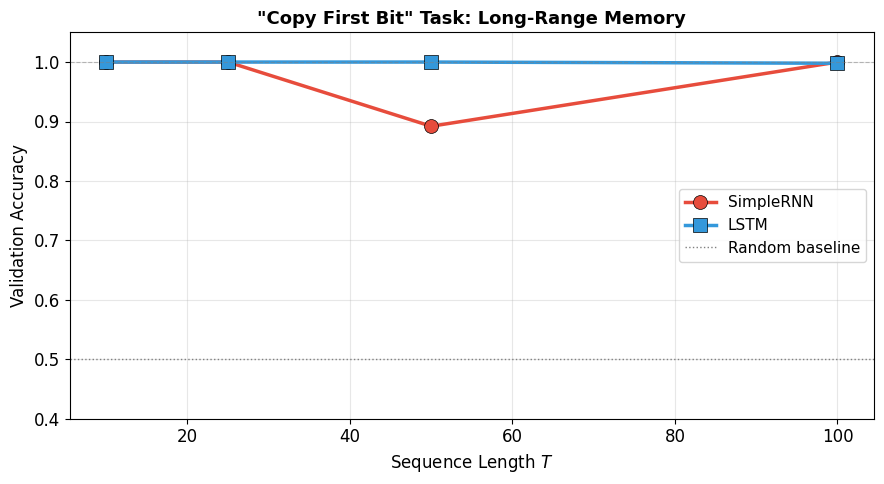

In [13]:
# Plot: accuracy vs. sequence length for RNN vs. LSTM
fig, ax = plt.subplots(figsize=(9, 5))

rnn_accs = [results[('SimpleRNN', T)] for T in seq_lengths]
lstm_accs = [results[('LSTM', T)] for T in seq_lengths]

ax.plot(seq_lengths, rnn_accs, 'o-', color='#e74c3c', linewidth=2.5,
        markersize=10, label='SimpleRNN', markeredgecolor='k', markeredgewidth=0.5)
ax.plot(seq_lengths, lstm_accs, 's-', color='#3498db', linewidth=2.5,
        markersize=10, label='LSTM', markeredgecolor='k', markeredgewidth=0.5)
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, label='Random baseline')
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

ax.set_xlabel('Sequence Length $T$', fontsize=12)
ax.set_ylabel('Validation Accuracy', fontsize=12)
ax.set_title('"Copy First Bit" Task: Long-Range Memory', fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
ax.set_ylim(0.4, 1.05)

plt.tight_layout()
plt.show()

**Observation:** The SimpleRNN collapses to random-guess accuracy ($\approx 0.5$) as the sequence length grows beyond ~25, while the LSTM maintains near-perfect accuracy even for $T = 100$. This is the constant error carousel in action: the forget gate can hold the first bit in the cell state $\mathbf{c}_t$ indefinitely.

**Experiment:**
- Reduce `hidden_dim` to 4 or 2. How small can the LSTM be and still solve this task? (Hint: it only needs to store one bit.)
- Try replacing `LSTM` with `GRU` (Gated Recurrent Unit). The GRU merges the forget and input gates into a single "update gate" — does it perform comparably?

---
# 3. Transformer Memory: The KV Cache

## 3.1 Attention as a soft dictionary lookup

Recall the self-attention mechanism from the [Architectures Overview](dnn_architectures_overview.ipynb):

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V.$$

We can reinterpret this as a **soft dictionary lookup**:

- Each past token $x_s$ stores a **key** $\mathbf{k}_s$ and a **value** $\mathbf{v}_s$ in memory.
- The current token produces a **query** $\mathbf{q}_t$.
- The output is a *weighted average* of stored values, with weights proportional to the query-key similarity:

$$\text{output}_t = \sum_{s=1}^{t} \alpha_{t,s} \, \mathbf{v}_s, \qquad \alpha_{t,s} = \frac{\exp(\mathbf{q}_t \cdot \mathbf{k}_s / \sqrt{d_k})}{\sum_{s'=1}^{t} \exp(\mathbf{q}_t \cdot \mathbf{k}_{s'} / \sqrt{d_k})}.$$

## 3.2 The KV cache during generation

During **autoregressive generation** (see [Generative Models](generative_models.ipynb)), the model generates one token at a time. Without caching, generating token $t$ would require recomputing the keys and values for *all* previous tokens — $O(t \cdot d)$ work per step, $O(T^2 d)$ total.

The **KV cache** stores all previously computed $(\mathbf{k}_s, \mathbf{v}_s)$ pairs, so each new step only needs to:
1. Compute $\mathbf{q}_t, \mathbf{k}_t, \mathbf{v}_t$ for the *new* token (one forward pass through the projection layers).
2. Append $\mathbf{k}_t, \mathbf{v}_t$ to the cache.
3. Compute attention over the full cache.

| | Without KV cache | With KV cache |
|---|---|---|
| Work per new token | $O(t \cdot d)$ (recompute all K, V) | $O(d^2 + t \cdot d)$ (project new token + attend) |
| Memory | $O(d)$ | $O(T \cdot d)$ per layer |
| Total to generate $T$ tokens | $O(T^2 \cdot d)$ | $O(T^2 \cdot d)$ attention + $O(T \cdot d^2)$ projections |

The KV cache trades **memory** for **compute**: it avoids redundant recomputation at the cost of storing all past keys and values. For a model with $L$ layers, $H$ attention heads, and key dimension $d_k$, the cache for a sequence of length $T$ requires $2 \times L \times H \times T \times d_k$ floating-point numbers.

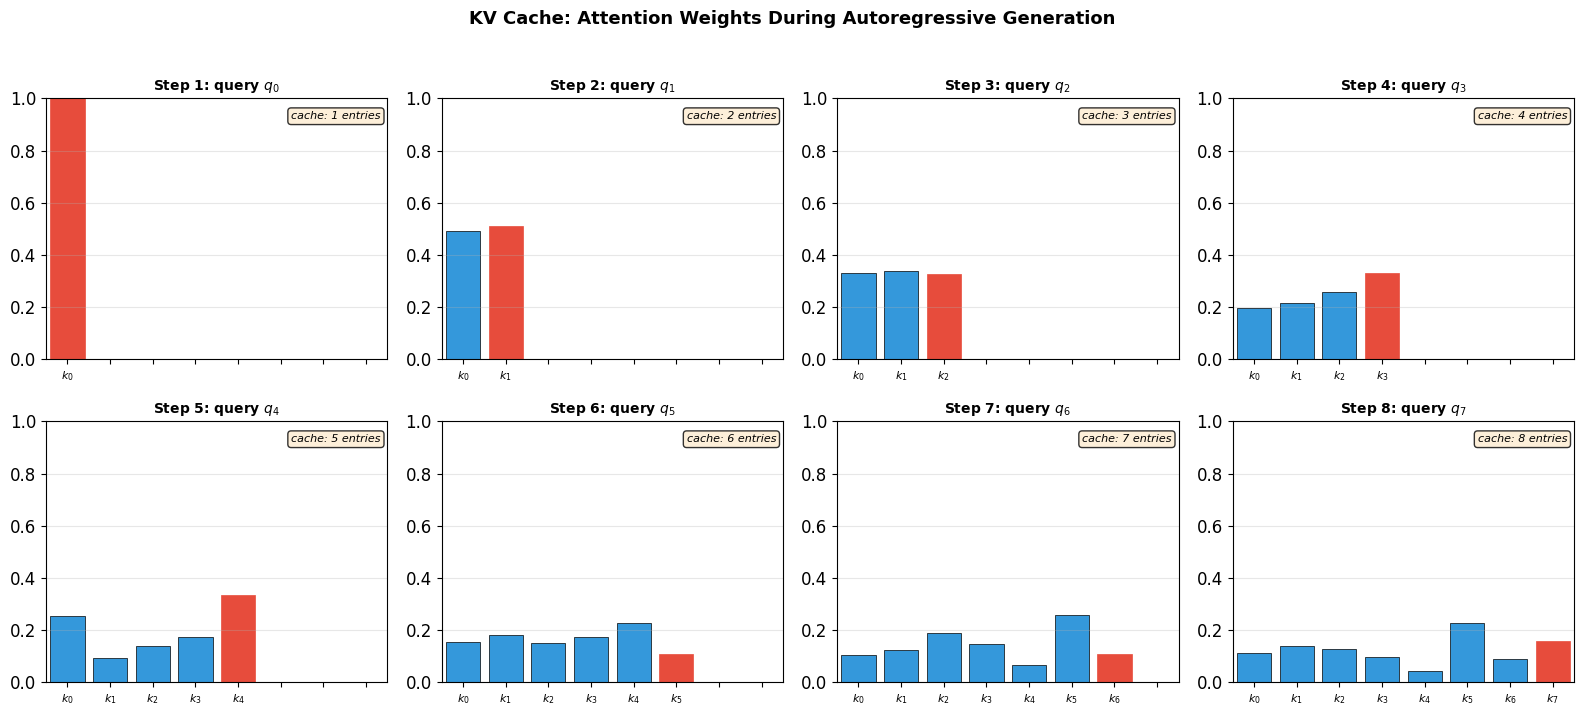

Final KV cache size: 8 entries × 4 dimensions = 32 floats (×2 for K and V)


In [14]:
# Interactive: visualize the KV cache growing during generation
# We manually compute attention step-by-step to show the cache

d_model = 8
d_k = 4
T_gen = 8  # number of tokens to "generate"

np.random.seed(7)
# Simulated token embeddings (pretend these come from an embedding layer)
X_tokens = np.random.randn(T_gen, d_model).astype(np.float32)

# Projection matrices
W_Q = np.random.randn(d_model, d_k).astype(np.float32) * 0.3
W_K = np.random.randn(d_model, d_k).astype(np.float32) * 0.3
W_V = np.random.randn(d_model, d_k).astype(np.float32) * 0.3

# Step-by-step generation with KV cache
K_cache = []
V_cache = []
attention_maps = []

for t in range(T_gen):
    q_t = X_tokens[t] @ W_Q  # query for new token
    k_t = X_tokens[t] @ W_K  # key for new token
    v_t = X_tokens[t] @ W_V  # value for new token

    K_cache.append(k_t)
    V_cache.append(v_t)

    K_mat = np.array(K_cache)  # (t+1, d_k)
    scores = (q_t @ K_mat.T) / np.sqrt(d_k)  # (t+1,)
    attn = np.exp(scores - scores.max())
    attn = attn / attn.sum()
    attention_maps.append(attn)

# Visualize: attention pattern at each generation step
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for t in range(T_gen):
    ax = axes[t]
    attn = attention_maps[t]
    bars = ax.bar(range(len(attn)), attn, color='#3498db', edgecolor='k', linewidth=0.5)
    # Highlight the newest key (self-attention to current token)
    bars[-1].set_color('#e74c3c')
    ax.set_xlim(-0.5, T_gen - 0.5)
    ax.set_ylim(0, 1)
    ax.set_xticks(range(T_gen))
    ax.set_xticklabels([f'$k_{s}$' if s <= t else '' for s in range(T_gen)], fontsize=8)
    ax.set_title(f'Step {t+1}: query $q_{t}$', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    # Show cache size
    ax.text(0.98, 0.92, f'cache: {t+1} entries', transform=ax.transAxes,
            ha='right', fontsize=8, style='italic',
            bbox=dict(boxstyle='round', facecolor='#fdebd0', alpha=0.8))

plt.suptitle('KV Cache: Attention Weights During Autoregressive Generation',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
print(f'Final KV cache size: {T_gen} entries × {d_k} dimensions = {T_gen * d_k} floats (×2 for K and V)')

**Key takeaway:** The KV cache gives the Transformer **perfect recall** of all past tokens — at any step $t$, it can attend to any previous position with equal ease. This is fundamentally different from an RNN, which must compress everything into a fixed-size vector.

The price is **linear memory growth**: for long contexts (e.g., $T = 100{,}000$ tokens), the KV cache can consume tens of gigabytes of GPU memory. This motivates the search for alternatives that scale better.

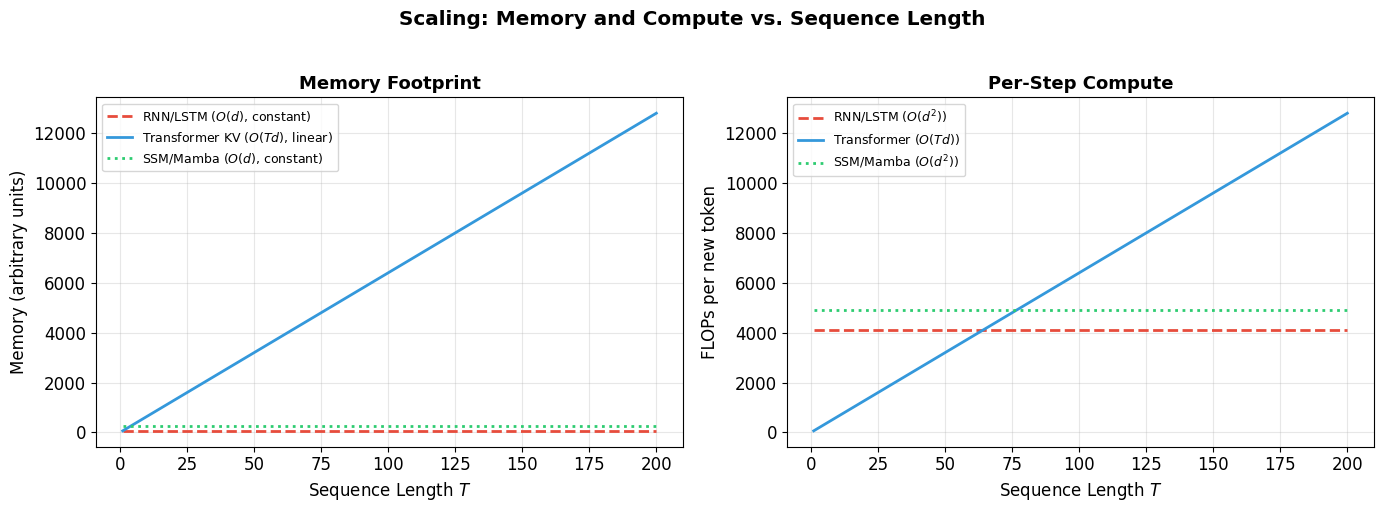

In [15]:
# Visualize: memory and compute scaling comparison
T_range = np.arange(1, 201)
d = 64  # model dimension (for illustration)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Memory
axes[0].plot(T_range, np.full_like(T_range, d, dtype=float), '--',
             color='#e74c3c', linewidth=2, label='RNN/LSTM ($O(d)$, constant)')
axes[0].plot(T_range, T_range * d, '-',
             color='#3498db', linewidth=2, label='Transformer KV ($O(Td)$, linear)')
axes[0].plot(T_range, np.full_like(T_range, d, dtype=float) * 4, ':',
             color='#2ecc71', linewidth=2, label='SSM/Mamba ($O(d)$, constant)')
axes[0].set_xlabel('Sequence Length $T$'); axes[0].set_ylabel('Memory (arbitrary units)')
axes[0].set_title('Memory Footprint', fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# Per-step compute
axes[1].plot(T_range, np.full_like(T_range, d**2, dtype=float), '--',
             color='#e74c3c', linewidth=2, label='RNN/LSTM ($O(d^2)$)')
axes[1].plot(T_range, T_range * d, '-',
             color='#3498db', linewidth=2, label='Transformer ($O(Td)$)')
axes[1].plot(T_range, np.full_like(T_range, d**2, dtype=float) * 1.2, ':',
             color='#2ecc71', linewidth=2, label='SSM/Mamba ($O(d^2)$)')
axes[1].set_xlabel('Sequence Length $T$'); axes[1].set_ylabel('FLOPs per new token')
axes[1].set_title('Per-Step Compute', fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.suptitle('Scaling: Memory and Compute vs. Sequence Length', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
# 4. State-Space Models and Mamba

## 4.1 Linear state-space models (SSMs)

A **structured state-space model** (Gu et al., 2021) defines a linear recurrence in continuous time, then discretizes it:

$$\begin{aligned}
\text{Continuous:} \quad \dot{\mathbf{h}}(t) &= A\,\mathbf{h}(t) + B\,x(t), \quad y(t) = C\,\mathbf{h}(t), \\
\text{Discrete:} \quad \mathbf{h}_t &= \bar{A}\,\mathbf{h}_{t-1} + \bar{B}\,x_t, \quad y_t = C\,\mathbf{h}_t,
\end{aligned}$$

where $\bar{A}, \bar{B}$ are obtained by discretizing the continuous parameters with a step size $\Delta$.

**The dual view** is the key mathematical insight:

$$\boxed{\text{Recurrence: } \mathbf{h}_t = \bar{A}\mathbf{h}_{t-1} + \bar{B}x_t \quad \Longleftrightarrow \quad \text{Convolution: } y = K * x, \text{ where } K_t = C\bar{A}^t\bar{B}.}$$

- **Recurrence mode** (like an RNN): process one token at a time with $O(d)$ memory and $O(d^2)$ per-step cost. Ideal for **generation**.
- **Convolution mode** (like a CNN): process the entire sequence in parallel with a precomputed kernel $K$. Ideal for **training**.

This duality means SSMs get the **best of both worlds**: parallel training like a Transformer and constant-memory inference like an RNN.

## 4.2 Mamba: selective state spaces

The limitation of linear SSMs is that $\bar{A}$ and $\bar{B}$ are **fixed** (input-independent), so the model cannot decide *what* to remember based on the content. **Mamba** (Gu & Dao, 2023) makes the parameters input-dependent:

$$\bar{B}_t = \bar{B}(x_t), \quad \bar{C}_t = \bar{C}(x_t), \quad \Delta_t = \Delta(x_t).$$

This "**selection mechanism**" breaks the convolution equivalence (since the kernel now depends on the input), but Mamba uses a hardware-efficient parallel scan algorithm to maintain near-linear training speed.

The intuition: Mamba's input-dependent $\Delta_t$ acts like a **learned gate** — when $\Delta_t$ is large, the model "lets in" new information; when $\Delta_t$ is small, it retains the old state. This is conceptually similar to the LSTM's input gate, but implemented through the discretization step size.

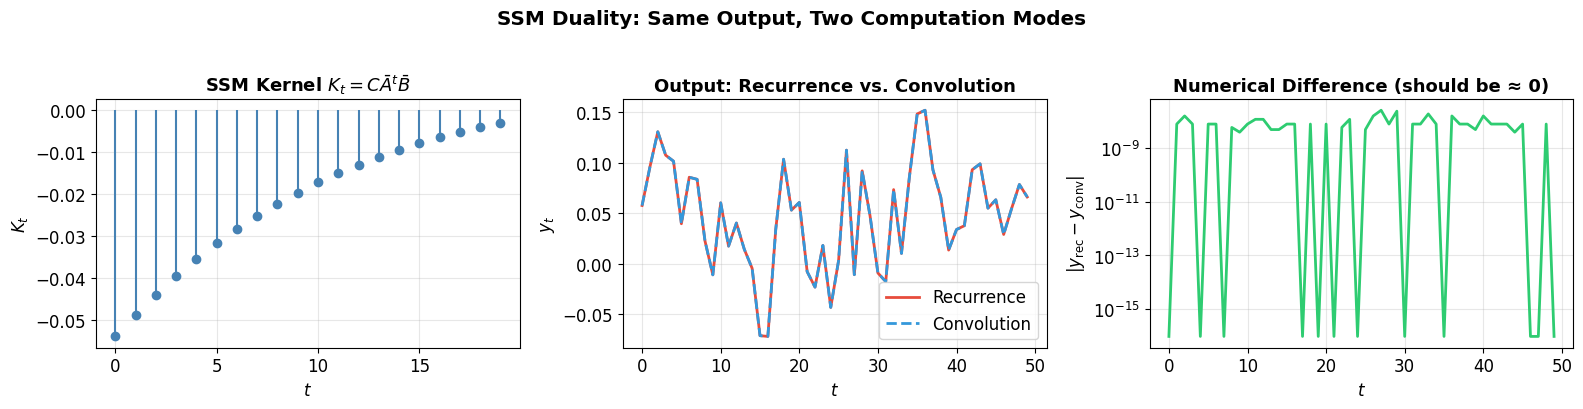

Max difference: 2.42e-08 (numerical precision)


In [16]:
# Demonstrate the recurrence ↔ convolution duality with a toy SSM

# Define a simple 1-D SSM
state_dim = 4
A_cont = -np.eye(state_dim) * 0.5 + np.diag(np.ones(state_dim - 1) * 0.3, 1)  # stable A
B_cont = np.random.randn(state_dim, 1).astype(np.float32) * 0.5
C_cont = np.random.randn(1, state_dim).astype(np.float32) * 0.5
Delta = 0.1  # discretization step

# Discretize: zero-order hold
A_bar = np.eye(state_dim) + Delta * A_cont  # Euler approximation
B_bar = Delta * B_cont

# Generate a random input sequence
T_ssm = 50
x_input = np.random.randn(T_ssm).astype(np.float32)

# --- Method 1: Recurrence ---
h = np.zeros(state_dim, dtype=np.float32)
y_recurrence = np.zeros(T_ssm, dtype=np.float32)
for t in range(T_ssm):
    h = A_bar @ h + B_bar.flatten() * x_input[t]
    y_recurrence[t] = (C_cont @ h).item()

# --- Method 2: Convolution ---
# Compute kernel K_t = C * A_bar^t * B_bar
K_kernel = np.zeros(T_ssm, dtype=np.float32)
A_power = np.eye(state_dim)
for t in range(T_ssm):
    K_kernel[t] = (C_cont @ A_power @ B_bar).item()
    A_power = A_power @ A_bar

y_convolution = np.convolve(x_input, K_kernel)[:T_ssm]

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].stem(range(min(20, T_ssm)), K_kernel[:20], linefmt='steelblue',
             markerfmt='o', basefmt=' ')
axes[0].set_xlabel('$t$'); axes[0].set_ylabel('$K_t$')
axes[0].set_title('SSM Kernel $K_t = C\\bar{A}^t\\bar{B}$', fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(y_recurrence, color='#e74c3c', linewidth=2, label='Recurrence')
axes[1].plot(y_convolution, '--', color='#3498db', linewidth=2, label='Convolution')
axes[1].set_xlabel('$t$'); axes[1].set_ylabel('$y_t$')
axes[1].set_title('Output: Recurrence vs. Convolution', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

diff = np.abs(y_recurrence - y_convolution)
axes[2].semilogy(diff + 1e-16, color='#2ecc71', linewidth=2)
axes[2].set_xlabel('$t$'); axes[2].set_ylabel('$|y_{\\text{rec}} - y_{\\text{conv}}|$')
axes[2].set_title('Numerical Difference (should be ≈ 0)', fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.suptitle('SSM Duality: Same Output, Two Computation Modes', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f'Max difference: {diff.max():.2e} (numerical precision)')

## 4.3 Selective gating: from linear SSM to Mamba

The plot below illustrates the key difference between a fixed-parameter SSM and Mamba's selective mechanism. In a standard SSM, the dynamics matrix $\bar{A}$ treats every input identically. In Mamba, the step size $\Delta_t$ adapts to the input, allowing the model to selectively **gate** information.

We simulate this with a toy example: a sequence contains "signal" tokens (that should be remembered) and "noise" tokens (that should be ignored). The input-dependent $\Delta_t$ learns to open the gate for signal and close it for noise.

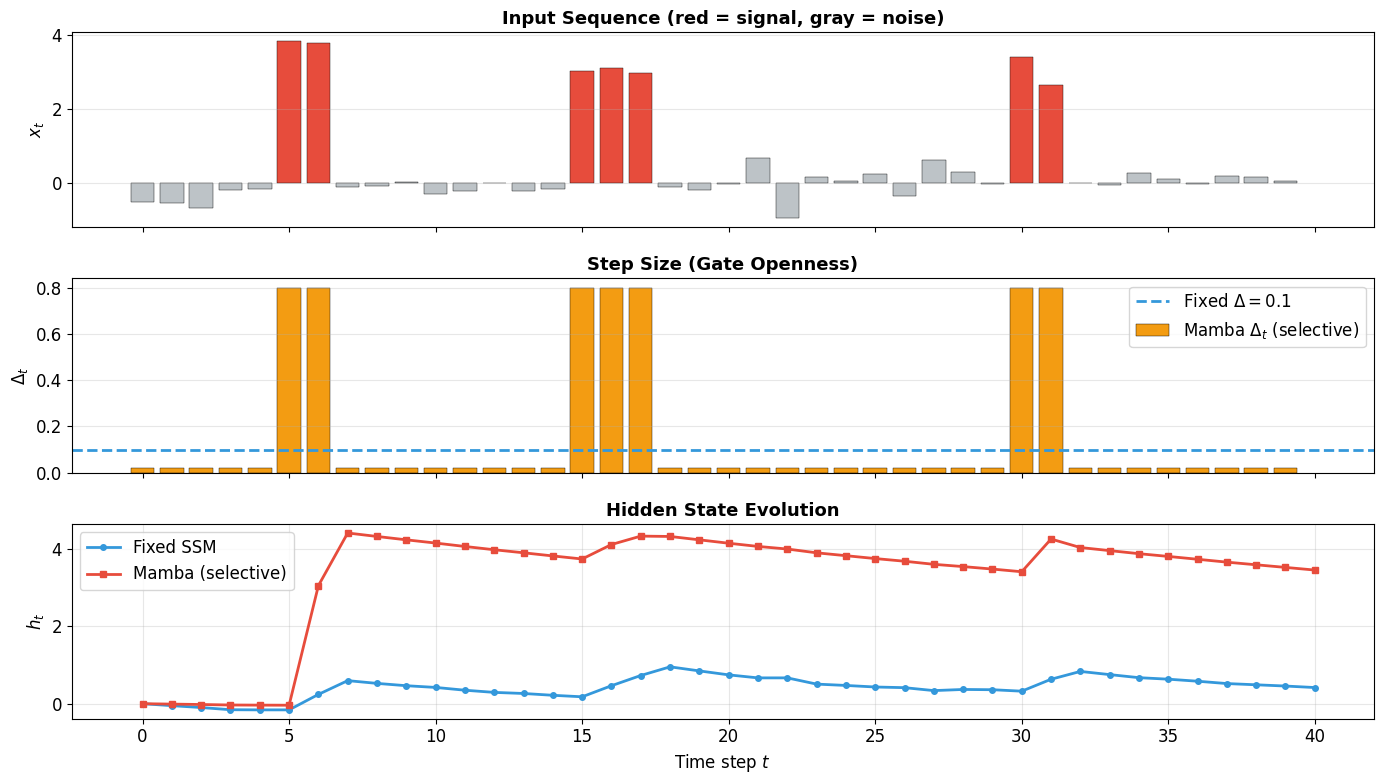

In [17]:
# Simulate selective gating: Mamba-style input-dependent Delta
T_sel = 40

# Create a sequence with "signal" (large values) and "noise" (small values)
np.random.seed(12)
is_signal = np.zeros(T_sel, dtype=bool)
signal_positions = [5, 6, 15, 16, 17, 30, 31]
is_signal[signal_positions] = True
x_seq = np.where(is_signal, np.random.uniform(2, 4, T_sel), np.random.randn(T_sel) * 0.3)
x_seq = x_seq.astype(np.float32)

# Fixed SSM (constant Delta)
delta_fixed = 0.1
a_scalar = 0.9
h_fixed = np.zeros(T_sel + 1, dtype=np.float32)
for t in range(T_sel):
    h_fixed[t + 1] = a_scalar * h_fixed[t] + delta_fixed * x_seq[t]

# Mamba-style (input-dependent Delta)
# Delta is large for signal, small for noise
delta_selective = np.where(is_signal, 0.8, 0.02).astype(np.float32)
h_selective = np.zeros(T_sel + 1, dtype=np.float32)
for t in range(T_sel):
    a_sel = np.exp(-delta_selective[t])  # discretized decay
    h_selective[t + 1] = a_sel * h_selective[t] + delta_selective[t] * x_seq[t]

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

# Input sequence
colors_seq = ['#e74c3c' if s else '#bdc3c7' for s in is_signal]
axes[0].bar(range(T_sel), x_seq, color=colors_seq, edgecolor='k', linewidth=0.3)
axes[0].set_ylabel('$x_t$')
axes[0].set_title('Input Sequence (red = signal, gray = noise)', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Delta values
axes[1].bar(range(T_sel), delta_selective, color='#f39c12', edgecolor='k', linewidth=0.3,
            label='Mamba $\\Delta_t$ (selective)')
axes[1].axhline(delta_fixed, color='#3498db', linewidth=2, linestyle='--',
                label=f'Fixed $\\Delta = {delta_fixed}$')
axes[1].set_ylabel('$\\Delta_t$')
axes[1].set_title('Step Size (Gate Openness)', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3, axis='y')

# Hidden states
axes[2].plot(range(T_sel + 1), h_fixed, '-o', color='#3498db', markersize=4,
             linewidth=2, label='Fixed SSM')
axes[2].plot(range(T_sel + 1), h_selective, '-s', color='#e74c3c', markersize=4,
             linewidth=2, label='Mamba (selective)')
axes[2].set_xlabel('Time step $t$'); axes[2].set_ylabel('$h_t$')
axes[2].set_title('Hidden State Evolution', fontweight='bold')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Key insight:** The selective $\Delta_t$ acts as a **content-based gate**: when $\Delta_t$ is large, new information flows into the state; when $\Delta_t \approx 0$, the state ignores the input and retains its current value. This is analogous to the LSTM's input gate, but arises from the *discretization step size* of a continuous dynamical system.

**Experiment:** Modify the `signal_positions` list. What happens if signal tokens are clustered together vs. spread apart? How does the selective state track multiple "memories" simultaneously?

---
# 5. Comparative Summary

| Feature | Simple RNN | LSTM | Transformer (KV) | SSM / Mamba |
|---|---|---|---|---|
| **Memory type** | Fixed vector $\mathbf{h}_t$ | Fixed vector $(\mathbf{h}_t, \mathbf{c}_t)$ | Growing KV cache | Fixed vector $\mathbf{h}_t$ |
| **Memory size** | $O(d)$ | $O(d)$ | $O(T \cdot d)$ | $O(d)$ |
| **Per-step cost** | $O(d^2)$ | $O(d^2)$ | $O(T \cdot d)$ | $O(d^2)$ |
| **Training** | Sequential ($O(Td^2)$) | Sequential ($O(Td^2)$) | Parallel ($O(T^2d)$) | Parallel (conv mode) or scan |
| **Long-range memory** | Poor (vanishing gradient) | Good (forget gate) | Perfect (explicit storage) | Good (structured $A$) |
| **Content-based retrieval** | No | Limited (gates) | Yes (attention) | Selective (Mamba) |
| **Generation speed** | Fast ($O(d^2)$/step) | Fast ($O(d^2)$/step) | Slow ($O(Td)$/step) | Fast ($O(d^2)$/step) |
| **Introduced** | 1990 | 1997 | 2017 | 2021/2023 |

The evolution of memory architectures reflects a fundamental tension in sequence modeling:

$$\text{compression} \quad \longleftrightarrow \quad \text{exact recall}.$$

RNNs and SSMs compress aggressively (fixed-size state), gaining speed but losing fidelity. Transformers keep everything (KV cache), gaining perfect recall but paying in memory and compute. The ideal memory architecture — and whether a single architecture can dominate on both axes — remains an open research question.

---
# 6. Where to Go Next

Topics we did not have time to cover:

- **Multi-head attention as parallel memory banks**: each attention head can specialize in different types of retrieval patterns (local, syntactic, semantic).
- **Sparse and linear attention**: methods like Linformer, Performer, and FlashAttention reduce the $O(T^2)$ cost of standard attention while retaining most of its recall ability.
- **Memory-augmented networks**: Neural Turing Machines and Differentiable Neural Computers use an external read/write memory matrix with explicit addressing.
- **Retrieval-augmented generation (RAG)**: instead of storing everything in parameters or a KV cache, retrieve relevant documents from an external database at inference time.
- **Hybrid architectures**: Jamba (AI21, 2024) interleaves Transformer layers with Mamba layers, getting attention's recall for critical layers and Mamba's efficiency for the rest.

---
# 7. Exercises

1. **LSTM gradient flow.** Show that for the LSTM cell update $\mathbf{c}_t = \mathbf{f}_t \odot \mathbf{c}_{t-1} + \mathbf{i}_t \odot \tilde{\mathbf{c}}_t$, the gradient $\partial \mathbf{c}_T / \partial \mathbf{c}_t = \prod_{s=t+1}^T \text{diag}(\mathbf{f}_s)$. Explain why this product does not vanish when $\mathbf{f}_s \approx 1$, and contrast this with the simple RNN gradient product.

2. **KV cache memory budget.** A Transformer has $L = 32$ layers, $H = 32$ attention heads, key dimension $d_k = 128$, and uses 16-bit floating point. How many bytes does the KV cache require for a sequence of length $T = 8{,}192$? At what sequence length does the cache exceed 16 GB?

3. **SSM kernel decay.** For the scalar SSM $h_t = a \cdot h_{t-1} + b \cdot x_t$ with $|a| < 1$, show that the convolution kernel decays exponentially: $K_t = c \cdot a^t \cdot b$. What does this imply about the model's effective "memory horizon"? Compute the half-life of the kernel for $a = 0.99$ and $a = 0.9$.

4. **GRU vs. LSTM.** Replace `LSTM` with `GRU` in the "copy first bit" experiment and compare accuracy across sequence lengths. The GRU has fewer parameters (it merges forget and input gates). Does this help or hurt on this task? Explain.

5. **Selective attention.** Design a sequence task where the model must *ignore* certain tokens (e.g., noise tokens marked with a special flag) and attend only to signal tokens. Compare the performance of (a) an LSTM, (b) a Transformer, and (c) the selective SSM simulation from Section 4.3. Which architecture handles the selection most naturally?